In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

Business Understanding
        ↓
Data Collection
        ↓
Dataset Understanding
        ↓
Data Cleaning 
        ↓
Handle Outliers (if required)
        ↓
Exploratory Data Analysis (EDA)
        ↓
Feature Engineering
        ↓
Encoding
        ↓
Define X and y
        ↓
Train-Test Split
        ↓
Feature Scaling (if required)
        ↓
(Optional) PCA / Feature Selection
        ↓
Train Multiple Models
        ↓
Cross Validation
        ↓
Hyperparameter Tuning
        ↓
Final Model Selection
        ↓
Evaluation on Test Set
        ↓
Save Model
        ↓
Deployment (Streamlit)
        ↓
GitHub + README

In [2]:
data  = pd.read_csv(r"C:\Users\shobh\OneDrive\Attachments\Documents\Desktop\py\creditcard.csv")


df = pd.DataFrame(data)


df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.duplicated().sum()
df.drop_duplicates(inplace = True)

| Class | Meaning                           |
| ----- | --------------------------------- |
| **0** | ✅ Legitimate (Normal) Transaction |
| **1** | 🚨 Fraudulent Transaction         |


<Axes: xlabel='Class', ylabel='count'>

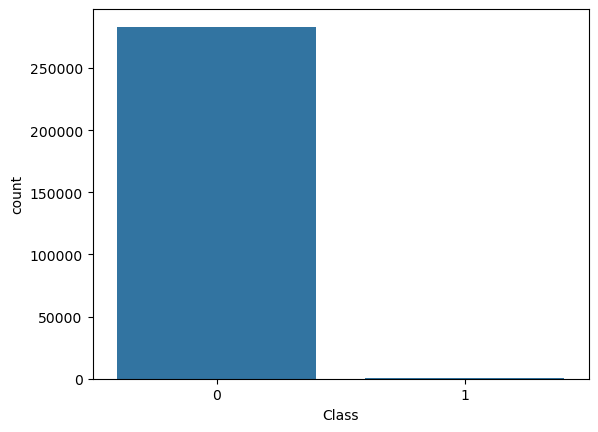

In [5]:
sns.countplot(x='Class', data=df)

In [6]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

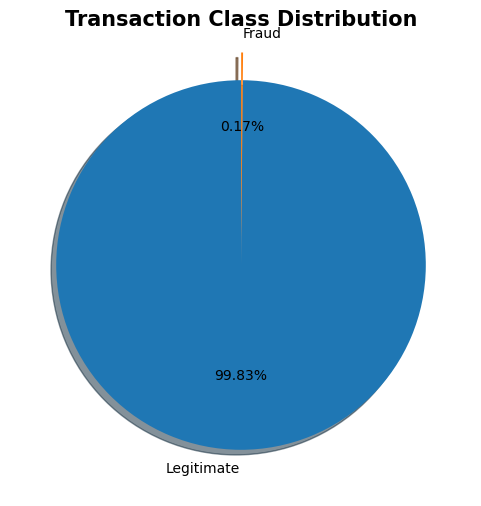

In [7]:
plt.figure(figsize=(6,6))

df['Class'].value_counts().plot(
    kind='pie',
    autopct='%1.2f%%',
    startangle=90,
    explode=[0,0.15],
    shadow=True,
    labels=['Legitimate','Fraud']
)

plt.title("Transaction Class Distribution", fontsize=15, fontweight='bold')
plt.ylabel("")
plt.show()

<Axes: xlabel='Amount', ylabel='Count'>

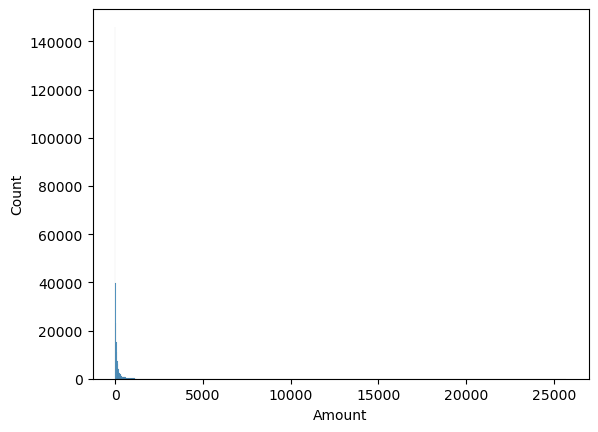

In [8]:
sns.histplot(df['Amount'])

<Axes: xlabel='Class', ylabel='Amount'>

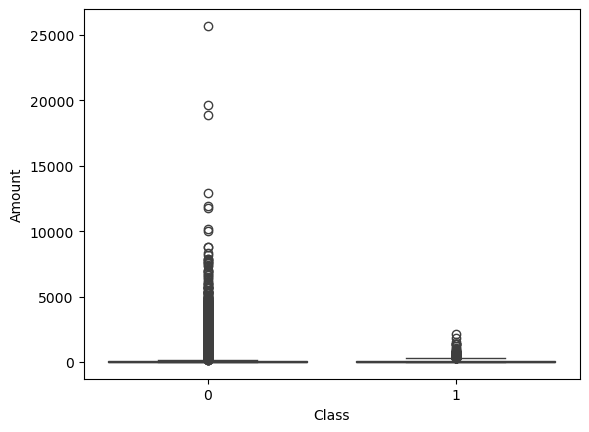

In [9]:
sns.boxplot(x='Class', y='Amount', data=df)

<Axes: xlabel='Time', ylabel='Count'>

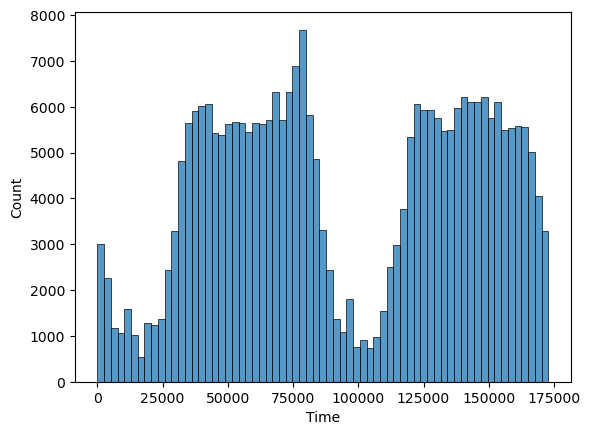

In [10]:
sns.histplot(df['Time'])

<Axes: xlabel='V1', ylabel='Count'>

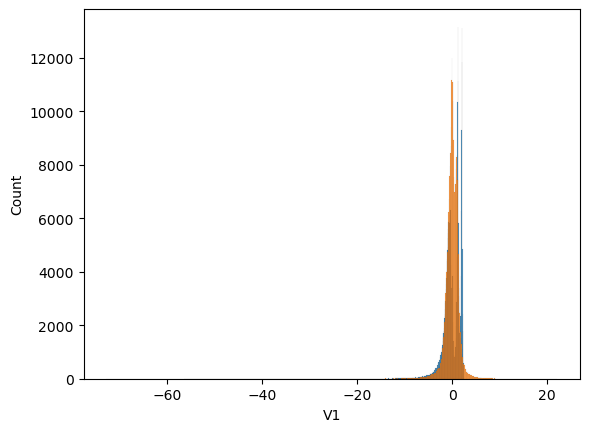

In [11]:
sns.histplot(df['V1'])
sns.histplot(df['V2'])

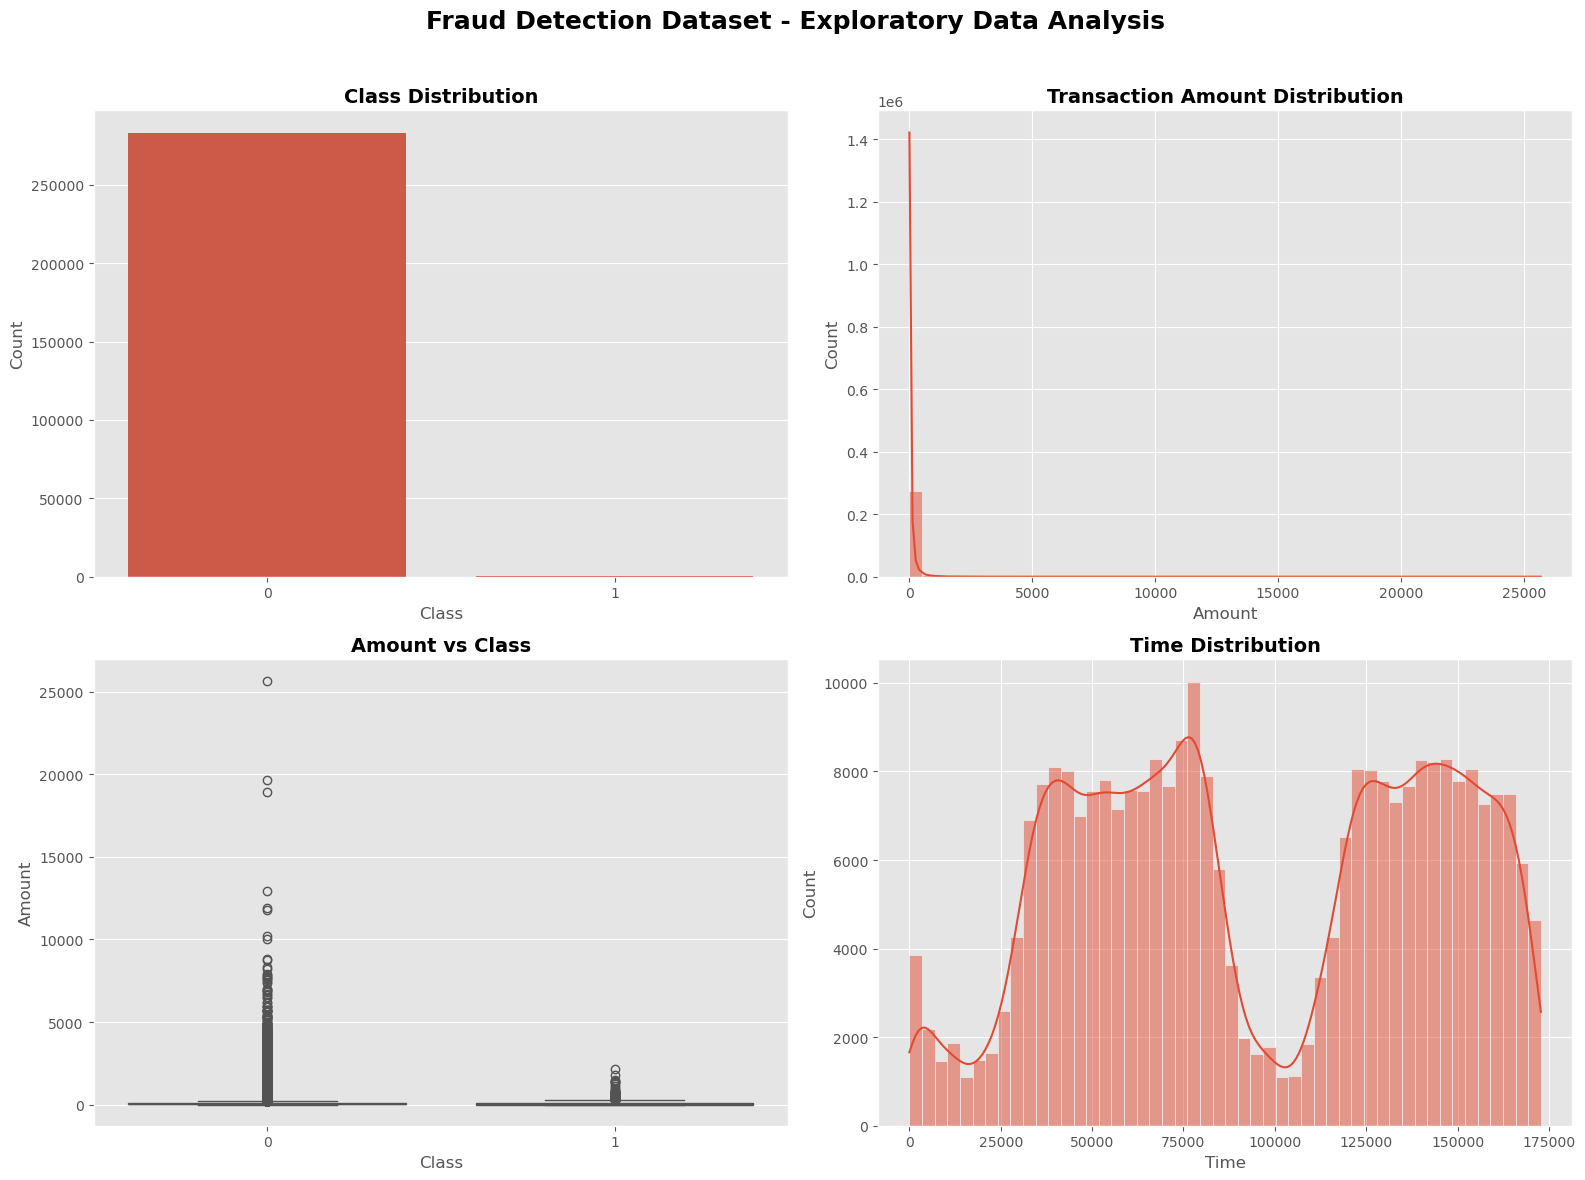

In [12]:
plt.style.use("ggplot")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.countplot(x='Class', data=df, ax=axes[0,0])
axes[0,0].set_title("Class Distribution", fontsize=14, fontweight='bold')
axes[0,0].set_xlabel("Class")
axes[0,0].set_ylabel("Count")

sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[0,1])
axes[0,1].set_title("Transaction Amount Distribution", fontsize=14, fontweight='bold')
axes[0,1].set_xlabel("Amount")
axes[0,1].set_ylabel("Count")

sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1,0])
axes[1,0].set_title("Amount vs Class", fontsize=14, fontweight='bold')
axes[1,0].set_xlabel("Class")
axes[1,0].set_ylabel("Amount")


sns.histplot(df['Time'], bins=50, kde=True, ax=axes[1,1])
axes[1,1].set_title("Time Distribution", fontsize=14, fontweight='bold')
axes[1,1].set_xlabel("Time")
axes[1,1].set_ylabel("Count")

plt.suptitle("Fraud Detection Dataset - Exploratory Data Analysis", fontsize=18, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [13]:
X = df.drop(columns='Class')

y = df['Class']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [15]:
#scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


<div style="background:white; border:3px solid #4F46E5; border-radius:20px; padding:30px;">

<h1 align="center" style="font-family:Georgia,serif; color:#4F46E5;">
📋 Machine Learning Models & Scaling Requirement
</h1>

<br>

<table style="width:100%; border-collapse:collapse; font-family:'Segoe UI',sans-serif;">

<tr style="background:#EDE9FE;">
<th style="border:1px solid #CBD5E1; padding:12px;">Model</th>
<th style="border:1px solid #CBD5E1; padding:12px;">Category</th>
<th style="border:1px solid #CBD5E1; padding:12px;">Scaling Required?</th>
<th style="border:1px solid #CBD5E1; padding:12px;">Use</th>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>Logistic Regression</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Classification</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#059669;"><b>✅ Yes</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_train_scaled</code>, <code>X_test_scaled</code></td>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>KNeighborsClassifier (KNN)</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Classification</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#059669;"><b>✅ Yes</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_train_scaled</code>, <code>X_test_scaled</code></td>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>SVC (Support Vector Machine)</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Classification</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#059669;"><b>✅ Yes</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_train_scaled</code>, <code>X_test_scaled</code></td>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>GaussianNB</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Classification</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#DC2626;"><b>❌ No</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_train</code>, <code>X_test</code></td>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>DecisionTreeClassifier</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Classification</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#DC2626;"><b>❌ No</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_train</code>, <code>X_test</code></td>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>RandomForestClassifier</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Ensemble Learning</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#DC2626;"><b>❌ No</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_train</code>, <code>X_test</code></td>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>AdaBoostClassifier</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Ensemble Learning</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#DC2626;"><b>❌ No</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_train</code>, <code>X_test</code></td>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>GradientBoostingClassifier</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Ensemble Learning</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#DC2626;"><b>❌ No</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_train</code>, <code>X_test</code></td>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>XGBClassifier</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Ensemble Learning</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#DC2626;"><b>❌ No</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_train</code>, <code>X_test</code></td>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>StackingClassifier</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Ensemble Learning</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#D97706;"><b>⚠️ Depends on the base models</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Usually same preprocessing as the base models</td>
</tr>
<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>KMeans</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Clustering</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#059669;"><b>✅ Yes</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_scaled</code></td>
</tr>

<tr>
<td style="border:1px solid #CBD5E1; padding:12px;"><b>DBSCAN</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;">Clustering</td>
<td style="border:1px solid #CBD5E1; padding:12px; color:#059669;"><b>✅ Yes</b></td>
<td style="border:1px solid #CBD5E1; padding:12px;"><code>X_scaled</code></td>
</tr>

</table>


</div>


In [16]:
# classification models that does require scaling

# Logistic Regression

# KNeighborsClassifier (KNN)

# SVC (Support Vector Machine)


# we will use a loop to evaluate all 3 models 

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

In [17]:
#function for later 

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return accuracy, precision, recall, f1

In [18]:
models = {

    "Logistic Regression": LogisticRegression(),

    "KNN": KNeighborsClassifier(),

}

In [19]:
results = []

for name, model in models.items():

    accuracy, precision, recall, f1 = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [20]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison.sort_values(
    by="F1 Score",
    ascending=False,
    inplace=True
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
1,KNN,0.999418,0.955882,0.684211,0.797546
0,Logistic Regression,0.999119,0.846154,0.578947,0.687500


In [21]:
#now model that needs scaling as well 



# GaussianNB

# DecisionTreeClassifier

# RandomForestClassifier

# AdaBoostClassifier

# GradientBoostingClassifier

# XGBClassifier

# StackingClassifier


NameError: name 'GaussianNB' is not defined

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier



def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return accuracy, precision, recall, f1


models = {

    "Gaussian Naive Bayes": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    )

}


results = []

for name, model in models.items():

    accuracy, precision, recall, f1 = evaluate_model(
        model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])



comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison